In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")

from seqAE_model import SeqAutoencoder
from contra_seq_dataset import ContraSeqDataset, get_dataset_array, get_anc_map
from losses import SupConLoss, padce_loss
from tqdm.notebook import tqdm
import torch
import random

from plot_utils import *

In [2]:
## Dataset

anc_path = 'model_dataset/anchor_smiles.csv'
aug_path = 'model_dataset/augmented_smiles_balanced.csv'

ds = ContraSeqDataset(anc_path, aug_path)
ds_arr = get_dataset_array(anc_path, aug_path)
anc_map = get_anc_map(ds_arr)

In [3]:
## Loader
from contra_seq_dataset import AnchoredSampler
from torch.utils.data import DataLoader, RandomSampler

# # # # # # # # # # # # # # #
BATCH_SIZE = 32 # this is the number of ANCHORS

sampler = AnchoredSampler(sampler = RandomSampler(list(anc_map.keys())), 
                          anc_map = anc_map, batch_size = BATCH_SIZE, drop_last = True)
loader = DataLoader(ds, batch_sampler=sampler, num_workers=0, pin_memory=True)

In [4]:
import os
from datetime import datetime

today = datetime.today().strftime('%Y%m%d%H')
v = 'a01'
tag = f'{today}_{v}' #'.pt'

model_dir = os.path.join('models',tag)

use_losses = ['Recon']
BS = 32
E = 50
NORMED_LATENT = True

print(model_dir)

models/2022041308_a01


In [5]:
def get_loss(use_losses, run_data, samp, dec_out, latent, BS):
    if 'Recon' in use_losses: 
        recon_loss = padce_loss(samp['seq'], dec_out.squeeze(), 
                                samp['pad_mask'], samp['out_mask'])  
        run_data['Recon'].append(recon_loss.item())
    if 'SupCon' in use_losses: 
        contra_loss = SupConLoss()(latent, labels=torch.tensor(range(BS)))
        run_data['SupCon'].append(contra_loss.item())
        
    
    if set(use_losses)==set(['Recon']):
        loss = recon_loss
    elif set(use_losses)==set(['SupCon']):
        loss = contra_loss
    elif set(use_losses)==set(['Recon','SupCon']):
        loss = recon_loss + contra_loss
    
    return (loss, run_data)

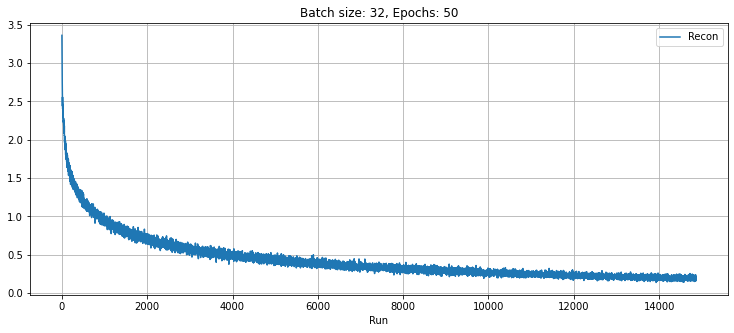

In [ ]:
import torch.nn as nn
import pandas as pd

model = SeqAutoencoder(n_tokens = ds.n_tokens, max_len = 122,
                       dim_emb=512, heads=8, dim_hidden=32,
                       L_enc=6, L_dec=6, dim_ff=2048, 
                       drpt=0.1, actv='relu', eps=0.6, b_first=True)

torch.cuda.empty_cache()
use_cuda = True
device =  torch.device("cuda" if use_cuda else "cpu")

if use_cuda and torch.cuda.device_count() > 1:
    print("Let's use", torch.cuda.device_count(), "GPUs!")
    model = nn.DataParallel(model)
    model.to(device)
else:
    model = model.to(device)
    
optimizer = torch.optim.Adam(model.parameters(), lr = 0.00001)    
model.train()

run_data = {k:[] for k in use_losses}

if not os.path.exists(model_dir):
    os.mkdir(model_dir)
    print(model_dir)
else:
    print("DIRECTORY EXISTS! ...",model_dir)
    
for i in range(E):
    ii = f'0{i}' if i < 10 else i
    model_path = f'{model_dir}/{ii}.pt'
    
    for samp in loader:
        
        optimizer.zero_grad()
        
        for k,v in samp.items():
            if torch.is_tensor(v):
                samp[k] = v.to(device)
        latent, dec_out = model.forward(samp['seq'], samp['pad_mask'], 
                                        samp['avg_mask'], samp['out_mask'], 
                                        normed=NORMED_LATENT)
        latent = torch.stack(torch.split(latent, 6), dim=0) # (BS, 6, 32)     
    
        loss, run_data = get_loss(use_losses, run_data, samp, dec_out, latent, BS)
        loss.backward()
        optimizer.step()
        
        live_plot(run_data, BS, E, figsize=(12.5,5))
        
    try:
        state_dict = model.module.state_dict()
    except AttributeError:
        state_dict = model.state_dict()
        
    if (i+1) % 5==0:
        torch.save(state_dict, model_path)
    
df_run = pd.DataFrame.from_dict(run_data)
df_run.to_csv(f'training_logs/losses_{tag}.csv')

In [ ]:
from platform import python_version
print(python_version())

In [ ]:
tag